# Attacks
How does test accuracy degrade under different attacks for the same topology.
Suppose training & validation for Classifier on all T3 attacks.

In [1]:
%load_ext autoreload
import sys
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.graph_factory import GraphFactory, add_graph_plot
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed
from lib.classifier import ByzClassifier
from lib.system import SystemSimulator
from lib.config import BASE_CONF, LOGFILE, NUM_NODES

In [4]:
RUN_DIR = Path().resolve()
config = BASE_CONF

In [5]:
global_dataset = fetch_dataset('MNIST')
gf = GraphFactory(config['train']['num_nodes'], config['train']['b'], seed('graph'))
proj_const_estimator = ProjConstEstimator(config, global_dataset, rng('proj-const-estimator')) 
clf = ByzClassifier(config, global_dataset, gf, rng('byz-classifier'))
sys_sim = SystemSimulator(config, global_dataset, rng('ml-system-sim'), LOGFILE)

In [6]:
prelim_metrics = dict()

In [7]:
proj_const_estimator.configure(gf,config)
proj_const = proj_const_estimator.estimate()
prelim_metrics['proj_const'] = proj_const

In [8]:
%%time
clf_sim_data = clf.run_simulations(config, proj_const, seed('clf','simulation-seed'), beta_C=0.1, gamma_C=0.12)

Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'](beta=0.1, gamma=0.12)
  train set (sim 70998088522)
  validation set (sim 45939939618)
  test set (sim 906269717930)
CPU times: user 28min 45s, sys: 38 s, total: 29min 23s
Wall time: 2min 6s


In [11]:
%%time
C_best_est, C_pre_pipe = clf.train_and_eval(model='rbf')

CPU times: user 33.8 s, sys: 96.2 ms, total: 33.9 s
Wall time: 15.9 s


In [13]:
C_op_pt = clf.calc_optimal_op_pt(quantile=0.85)
C_metrics = clf.test()

prelim_metrics.update(C_op_pt)
prelim_metrics.update(C_metrics)

display(pd.DataFrame([C_metrics]))

,prevalence,tau,tn,fp,fn,tp,beta_C,gamma_C,roc_auc,avg_prec
0,0.175,0.612314,29798,3202,678,6322,0.096857,0.09703,0.959238,0.882923


,n,prevalence,recall,beta_C,gamma_C,roc_auc
attack,,,,,,
label_flip,8000,0.175,0.948571,0.051429,0.068788,0.985565
sign_flip,8000,0.175,0.694286,0.305714,0.127424,0.858559
gaussian,8000,0.175,1.000000,0.000000,0.099091,0.991451
ALIE,8000,0.175,0.990000,0.010000,0.094848,0.993724
IPM,8000,0.175,0.882857,0.117143,0.095000,0.959338


In [14]:
%%capture
fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
clf.plot_pr(ax[1,2])

In [15]:
sys_sim.configure(gf, config, proj_const, C_pre_pipe, C_best_est, C_op_pt)

In [17]:
run_results = dict()
sim_params = {'algorithms': ['RDSGD', 'IOS', 'SCC', 'TriMean', 'CooMed', 'DSGD'], 
              'atk_type': None, 
              'threat_model': 'T0', 
              'seed': 222}
df_t0 = sys_sim.simulate(sim_params, run_results)

==========RDSGD==========
[k=50] train_loss: [1.401,1.633],test_acc: [0.784,0.863]
[k=100] train_loss: [1.382,1.645],test_acc: [0.737,0.865]
[k=150] train_loss: [1.378,1.647],test_acc: [0.732,0.865]
===========IOS===========
[k=50] train_loss: [1.437,1.708],test_acc: [0.831,0.854]
[k=100] train_loss: [1.409,1.789],test_acc: [0.835,0.850]
[k=150] train_loss: [1.390,1.839],test_acc: [0.812,0.843]
===========SCC===========
[k=50] train_loss: [1.465,1.679],test_acc: [0.862,0.863]
[k=100] train_loss: [1.468,1.685],test_acc: [0.863,0.864]
[k=150] train_loss: [1.470,1.684],test_acc: [0.864,0.864]
=========TriMean=========
[k=50] train_loss: [1.457,1.698],test_acc: [0.852,0.861]
[k=100] train_loss: [1.464,1.722],test_acc: [0.857,0.863]
[k=150] train_loss: [1.470,1.725],test_acc: [0.859,0.863]
==========CooMed=========
[k=50] train_loss: [1.481,1.743],test_acc: [0.857,0.861]
[k=100] train_loss: [1.480,1.746],test_acc: [0.859,0.861]
[k=150] train_loss: [1.482,1.742],test_acc: [0.860,0.861]
=====

In [18]:
ATKS = ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM']
ALGS = ['RDSGD', 'IOS', 'SCC', 'TriMean', 'CooMed']
COLORS = dict(zip(ALGS, ['C0', 'C1', 'C2', 'C3', 'C4']))
SEEDS = [777, 111, 555, 444, 888]

rows, payloads = [], []
for atk in ATKS:
    for s in SEEDS:
        sim_params = {'algorithms': ALGS, 'atk_type': atk,
                      'threat_model': 'T3', 'seed': s}
        run_results = {'timestamp': pd.to_datetime(datetime.now()), **prelim_metrics}

        t0 = time.perf_counter()
        df = sys_sim.simulate(sim_params, run_results)
        run_results['wall_s'] = time.perf_counter() - t0

        print(f"seed:{s}, atk:{atk} [{pd.to_timedelta(run_results['wall_s'], unit='s')}]")
        display(pd.DataFrame([{alg:run_results[f'T3_{alg}']['test_acc'] for alg in ALGS}]))
        
        payloads.append(sys_sim.log_results(run_results, RUN_DIR, generate()))
        for alg in ALGS:
            acc = df.loc[alg, 'min_test_acc']
            axis.plot(np.arange(len(acc)), acc, color=COLORS[alg],
                      alpha=0.35, label=alg if s == SEEDS[0] else None)
            rows.append({'atk': atk, 'alg': alg, 'seed': s,
                         'test_acc': run_results[f'T3_{alg}']['test_acc'],
                         'max_train_loss': df.loc[alg, 'max_train_loss'].iloc[-1],
                         'mean_test_acc': df.loc[alg, 'mean_test_acc'].iloc[-1],
                         'Ck': df.loc[alg, 'Ck'].iloc[-1],
                        })
    axis.set_title(f'T3: {atk}')

==========RDSGD==========
[k=50] train_loss: [1.125,1.695],test_acc: [0.466,0.858]
[k=100] train_loss: [1.121,1.730],test_acc: [0.474,0.856]
[k=150] train_loss: [1.119,1.739],test_acc: [0.473,0.856]
===========IOS===========
[k=50] train_loss: [1.409,1.684],test_acc: [0.823,0.855]
[k=100] train_loss: [1.416,1.705],test_acc: [0.829,0.854]
[k=150] train_loss: [1.414,1.734],test_acc: [0.829,0.851]
===========SCC===========
[k=50] train_loss: [1.499,1.704],test_acc: [0.851,0.855]
[k=100] train_loss: [1.507,1.707],test_acc: [0.852,0.854]
[k=150] train_loss: [1.506,1.711],test_acc: [0.853,0.855]
=========TriMean=========
[k=50] train_loss: [1.480,1.707],test_acc: [0.846,0.860]
[k=100] train_loss: [1.492,1.719],test_acc: [0.852,0.860]
[k=150] train_loss: [1.495,1.729],test_acc: [0.855,0.860]
==========CooMed=========
[k=50] train_loss: [1.521,1.752],test_acc: [0.851,0.857]
[k=100] train_loss: [1.519,1.757],test_acc: [0.854,0.858]
[k=150] train_loss: [1.518,1.766],test_acc: [0.855,0.859]
seed:

,RDSGD,IOS,SCC,TriMean,CooMed
0,0.85974,0.83961,0.853377,0.857273,0.857489


==========RDSGD==========
[k=50] train_loss: [1.127,1.695],test_acc: [0.456,0.857]
[k=100] train_loss: [1.121,1.715],test_acc: [0.469,0.857]
[k=150] train_loss: [1.119,1.712],test_acc: [0.470,0.856]
===========IOS===========
[k=50] train_loss: [1.416,1.696],test_acc: [0.824,0.850]
[k=100] train_loss: [1.415,1.709],test_acc: [0.828,0.852]
[k=150] train_loss: [1.413,1.738],test_acc: [0.831,0.852]
===========SCC===========
[k=50] train_loss: [1.498,1.714],test_acc: [0.844,0.848]
[k=100] train_loss: [1.504,1.718],test_acc: [0.844,0.847]
[k=150] train_loss: [1.508,1.721],test_acc: [0.845,0.846]
=========TriMean=========
[k=50] train_loss: [1.476,1.732],test_acc: [0.838,0.855]
[k=100] train_loss: [1.488,1.742],test_acc: [0.844,0.854]
[k=150] train_loss: [1.492,1.748],test_acc: [0.847,0.853]
==========CooMed=========
[k=50] train_loss: [1.518,1.782],test_acc: [0.839,0.849]
[k=100] train_loss: [1.516,1.786],test_acc: [0.843,0.848]
[k=150] train_loss: [1.514,1.790],test_acc: [0.845,0.849]
seed:

,RDSGD,IOS,SCC,TriMean,CooMed
0,0.85974,0.840866,0.845195,0.850606,0.846667


==========RDSGD==========
[k=50] train_loss: [1.127,1.700],test_acc: [0.459,0.857]
[k=100] train_loss: [1.121,1.719],test_acc: [0.462,0.857]
[k=150] train_loss: [1.119,1.724],test_acc: [0.471,0.858]
===========IOS===========
[k=50] train_loss: [1.413,1.682],test_acc: [0.827,0.854]
[k=100] train_loss: [1.413,1.687],test_acc: [0.828,0.855]
[k=150] train_loss: [1.409,1.712],test_acc: [0.830,0.854]
===========SCC===========
[k=50] train_loss: [1.505,1.704],test_acc: [0.849,0.853]
[k=100] train_loss: [1.511,1.710],test_acc: [0.850,0.853]
[k=150] train_loss: [1.509,1.713],test_acc: [0.851,0.853]
=========TriMean=========
[k=50] train_loss: [1.465,1.721],test_acc: [0.844,0.857]
[k=100] train_loss: [1.473,1.743],test_acc: [0.848,0.856]
[k=150] train_loss: [1.474,1.762],test_acc: [0.850,0.856]
==========CooMed=========
[k=50] train_loss: [1.505,1.781],test_acc: [0.844,0.854]
[k=100] train_loss: [1.500,1.797],test_acc: [0.847,0.853]
[k=150] train_loss: [1.495,1.807],test_acc: [0.848,0.851]
seed:

...

,RDSGD,IOS,SCC,TriMean,CooMed
0,0.859654,0.839697,0.85961,0.855974,0.855065


==========RDSGD==========
[k=50] train_loss: [1.127,1.639],test_acc: [0.476,0.859]
[k=100] train_loss: [1.121,1.630],test_acc: [0.479,0.860]
[k=150] train_loss: [1.119,1.631],test_acc: [0.481,0.857]
===========IOS===========
[k=50] train_loss: [1.451,1.681],test_acc: [0.834,0.852]
[k=100] train_loss: [1.417,1.730],test_acc: [0.833,0.853]
[k=150] train_loss: [1.417,1.746],test_acc: [0.833,0.850]
===========SCC===========
[k=50] train_loss: [1.463,1.665],test_acc: [0.853,0.857]
[k=100] train_loss: [1.464,1.668],test_acc: [0.857,0.858]
[k=150] train_loss: [1.467,1.670],test_acc: [0.858,0.859]
=========TriMean=========
[k=50] train_loss: [1.462,1.666],test_acc: [0.843,0.854]
[k=100] train_loss: [1.468,1.682],test_acc: [0.850,0.856]
[k=150] train_loss: [1.476,1.687],test_acc: [0.851,0.857]
==========CooMed=========
[k=50] train_loss: [1.486,1.688],test_acc: [0.846,0.853]
[k=100] train_loss: [1.483,1.696],test_acc: [0.851,0.855]
[k=150] train_loss: [1.487,1.699],test_acc: [0.853,0.855]
seed:

,RDSGD,IOS,SCC,TriMean,CooMed
0,0.863723,0.84,0.858485,0.855152,0.854502


==========RDSGD==========
[k=50] train_loss: [1.126,1.653],test_acc: [0.477,0.857]
[k=100] train_loss: [1.121,1.628],test_acc: [0.471,0.856]
[k=150] train_loss: [1.119,1.606],test_acc: [0.472,0.839]
===========IOS===========
[k=50] train_loss: [1.427,1.680],test_acc: [0.838,0.855]
[k=100] train_loss: [1.406,1.726],test_acc: [0.838,0.855]
[k=150] train_loss: [1.408,1.767],test_acc: [0.835,0.851]
===========SCC===========
[k=50] train_loss: [1.458,1.671],test_acc: [0.853,0.857]
[k=100] train_loss: [1.462,1.671],test_acc: [0.857,0.859]
[k=150] train_loss: [1.464,1.673],test_acc: [0.858,0.860]
=========TriMean=========
[k=50] train_loss: [1.449,1.677],test_acc: [0.844,0.855]
[k=100] train_loss: [1.465,1.685],test_acc: [0.851,0.857]
[k=150] train_loss: [1.473,1.691],test_acc: [0.853,0.856]
==========CooMed=========
[k=50] train_loss: [1.479,1.698],test_acc: [0.848,0.853]
[k=100] train_loss: [1.481,1.704],test_acc: [0.853,0.854]
[k=150] train_loss: [1.483,1.704],test_acc: [0.853,0.855]
seed:

,RDSGD,IOS,SCC,TriMean,CooMed
0,0.862771,0.840433,0.859524,0.855931,0.855022


In [67]:
summary_t3 = (pd.DataFrame(rows).groupby(['atk', 'alg'])['test_acc'].agg(['mean', 'std']).unstack('alg'))
summary_t3.to_csv("summary_t3")
display(summary_t3)

mean                                               std  \
alg           CooMed       IOS     RDSGD       SCC   TriMean    CooMed   
atk                                                                      
ALIE        0.851169  0.834147  0.859792  0.860165  0.850649  0.000567   
IPM         0.854632  0.840442  0.863004  0.859082  0.855359  0.000397   
gaussian    0.845939  0.820147  0.864571  0.856113  0.852320  0.001733   
label_flip  0.852009  0.841195  0.860433  0.850952  0.853766  0.004118   
sign_flip   0.833792  0.835524  0.862286  0.839229  0.843134  0.001806   

                                                    
alg              IOS     RDSGD       SCC   TriMean  
atk                                                 
ALIE        0.005129  0.004312  0.000475  0.000484  
IPM         0.003995  0.002065  0.000514  0.000588  
gaussian    0.010125  0.000635  0.001354  0.001823  
label_flip  0.001330  0.000666  0.003350  0.002494  
sign_flip   0.002442  0.000885  0.000694  0.001250

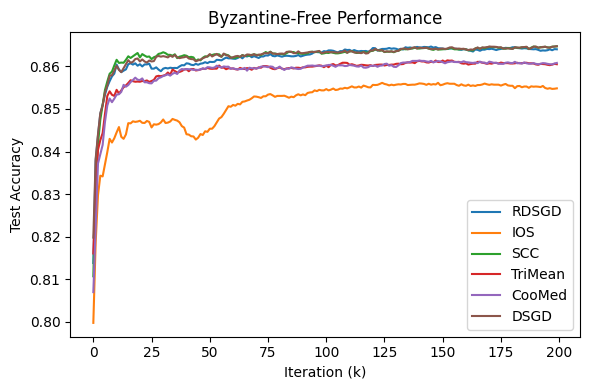

In [66]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
for alg in ['RDSGD', 'IOS', 'SCC', 'TriMean', 'CooMed', 'DSGD']:
    ax.plot(df_t0.loc[alg]['test_acc'], label=alg)
ax.legend()
ax.set(title='Byzantine-Free Performance', xlabel='Iteration (k)', ylabel='Test Accuracy')
fig.tight_layout()
plt.savefig("T0_test_acc.png")

In [73]:
def convert(o):
    if isinstance(o, np.generic):
        return o.item()
    raise TypeError(f'{type(o)} not serializable')
    
config.update(prelim_metrics)
config['classifier_model_type'] = 'rbf'
config['train_beta_C'] = 0.1 
config['train_gamma_C'] =0.12
with open('config.json', 'w') as f:
    json.dump(config, f, indent=2, default=convert)